In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data= pd.read_csv('/content/Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


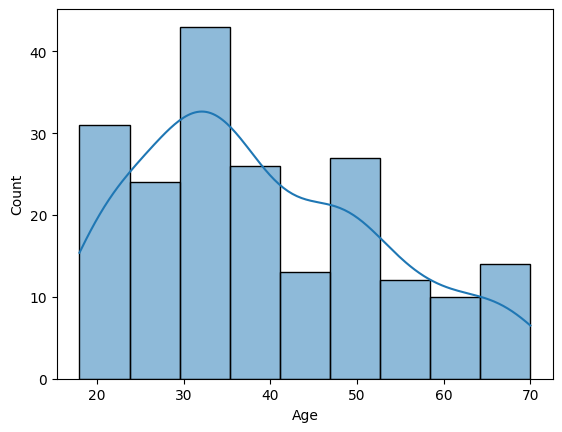

In [ ]:
sns.histplot(data['Age'], kde=True)
plt.show()

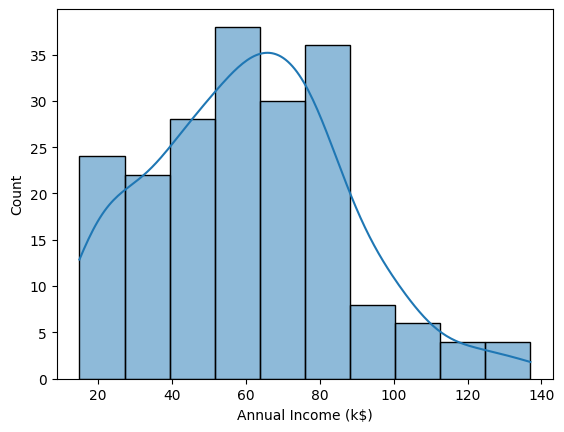

In [ ]:
sns.histplot(data['Annual Income (k$)'], kde=True)
plt.show()

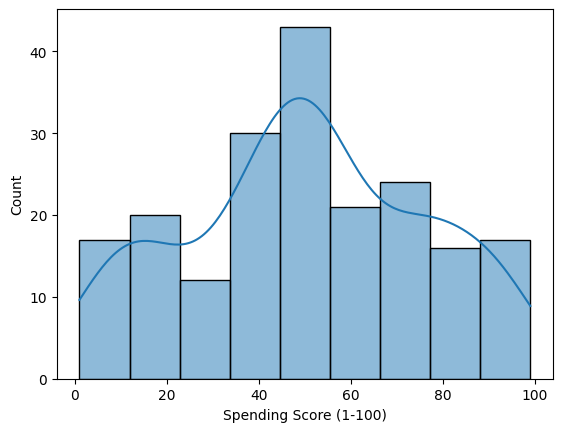

In [ ]:
sns.histplot(data['Spending Score (1-100)'], kde=True)
plt.show()

# Outliers

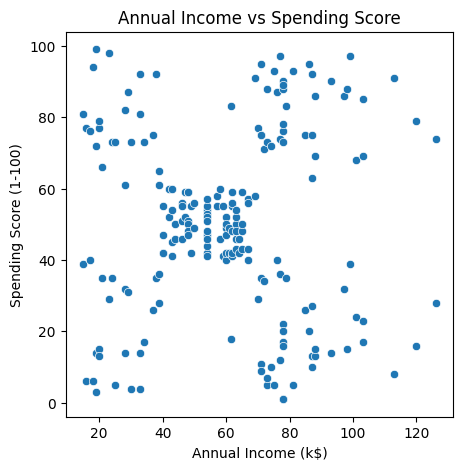

In [ ]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
#Annual income
Q1_income= data['Annual Income (k$)'].quantile(0.25)
Q3_income= data['Annual Income (k$)'].quantile(0.75)

IQR_income= Q3_income - Q1_income

lower_bound_income= Q1_income - 1.5 * IQR_income
upper_bound_income= Q3_income + 1.5 * IQR_income

#Spending Score
Q1_spend= data['Spending Score (1-100)'].quantile(0.25)
Q3_spend= data['Spending Score (1-100)'].quantile(0.75)

IQR_spend= Q3_spend - Q1_spend

lower_bound_spending= Q1_spend - 1.5 * IQR_spend
upper_bound_spending= Q3_spend + 1.5 * IQR_spend

outliers= data[(data['Annual Income (k$)'] < lower_bound_income) |
               (data['Annual Income (k$)'] > upper_bound_income) |
               (data['Spending Score (1-100)'] < lower_bound_spending) |
               (data['Spending Score (1-100)'] > upper_bound_spending)]

print(outliers)

     CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
198         199   Male   32                 137                      18
199         200   Male   30                 137                      83


In [ ]:
median_income = data['Annual Income (k$)'].median()
data.loc[data['Annual Income (k$)'] > upper_bound_income, 'Annual Income (k$)'] = median_income

/tmp/ipython-input-339/3874571566.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '61.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['Annual Income (k$)'] > upper_bound_income, 'Annual Income (k$)'] = median_income


In [ ]:
#Missing values

data.isnull().mean()

,0
CustomerID,0.0
Gender,0.0
Age,0.0
Annual Income (k$),0.0
Spending Score (1-100),0.0


In [ ]:
#Check Dupes
print(data.duplicated().any())

False


In [ ]:
#Drop Customer ID column
data = data.drop('CustomerID', axis=1)

In [ ]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15.0,39
1,Male,21,15.0,81
2,Female,20,16.0,6
3,Female,23,16.0,77
4,Female,31,17.0,40


In [ ]:
#Gender replacing
data['Gender'] = data['Gender'].replace({'Male': 0, 'Female': 1})

/tmp/ipython-input-339/1441905150.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Male': 0, 'Female': 1})


In [ ]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15.0,39,2
1,0,21,15.0,81,2
2,1,20,16.0,6,1
3,1,23,16.0,77,1
4,1,31,17.0,40,1


# scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df= data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)
scaled_data = scaler.fit_transform(df)


In [ ]:
scaled_data[:5]

array([[0.        , 0.01923077, 0.        , 0.3877551 ],
       [0.        , 0.05769231, 0.        , 0.81632653],
       [1.        , 0.03846154, 0.00900901, 0.05102041],
       [1.        , 0.09615385, 0.00900901, 0.7755102 ],
       [1.        , 0.25      , 0.01801802, 0.39795918]])

# K-Means clustering

# Elbow Method to define the number of clusters

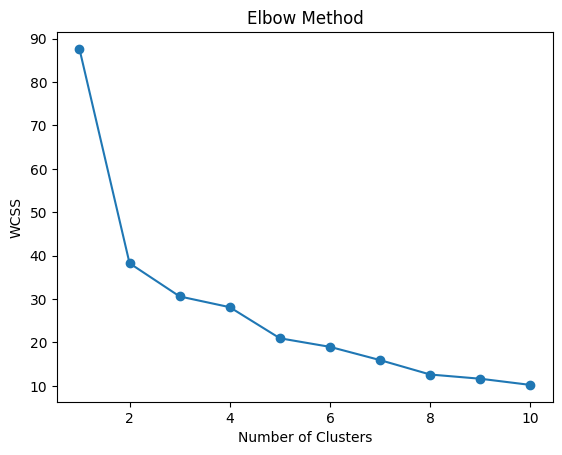

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15.0,39,2
1,0,21,15.0,81,2
2,1,20,16.0,6,1
3,1,23,16.0,77,1
4,1,31,17.0,40,1


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

data['Cluster'] = clusters

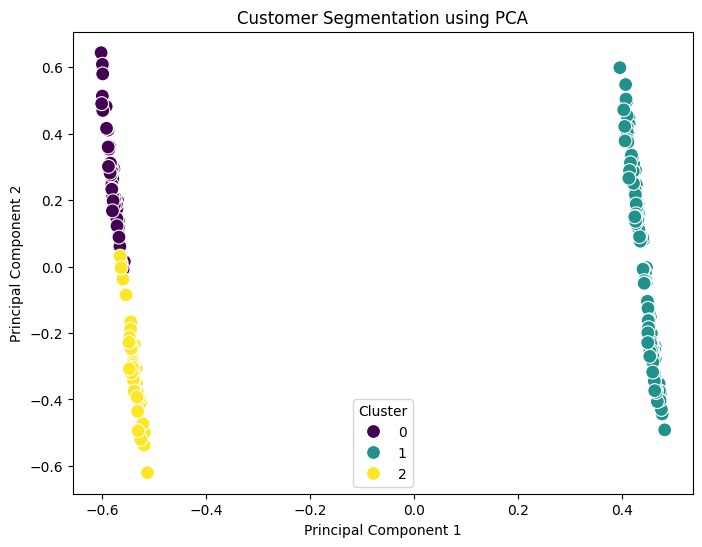

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=data['Cluster'],
    palette='viridis',
    s=100
)

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()